# ⭐ Day 40: MNIST Digits EDA  
### Image Data Exploration Starter for Computer Vision  
**Day 40 of 369-day Python & AI Learning Path** 🚀


## Welcome to Image Data Exploration! 🖼️

Today marks a pivotal moment in your data science journey — we're transitioning from the familiar world of **tabular data** (rows and columns of numbers) into the rich, visual realm of **image data**. While spreadsheets and CSV files have served us well for structured analysis, the real world is visual. From medical imaging to autonomous vehicles, from facial recognition to satellite imagery, understanding how to work with image data is one of the most valuable skills in modern AI.

### Why MNIST? 🔢

The **MNIST dataset** (Modified National Institute of Standards and Technology database) is affectionately known as the **"Hello World" of computer vision**. Just as every programmer starts with printing "Hello World," every computer vision practitioner begins with MNIST. This dataset contains 70,000 grayscale images of handwritten digits (0-9), each sized at 28×28 pixels. It's the perfect sandbox for learning because it's complex enough to be interesting, yet simple enough to process quickly and interpret intuitively.

### What You'll Learn Today 💡

In this notebook, you'll develop foundational skills for **Exploratory Data Analysis (EDA) on image datasets**. We'll learn how to load image data, inspect pixel values, visualize samples, analyze class distributions, and understand the statistical properties of visual data. These skills aren't just applicable to MNIST — they're the same techniques you'll use for medical scans, satellite photos, or any image-based machine learning project.

By the end of Day 40, you'll understand how computers "see" images as arrays of numbers, how to spot patterns in visual data, and how to prepare images for machine learning models. Let's dive into the pixels! 🎨


## 📋 Table of Contents

1. [Introduction to Image Data and MNIST Dataset](#1-introduction-to-image-data-and-mnist-dataset)
2. [Loading the MNIST Dataset](#2-loading-the-mnist-dataset)
3. [Basic Image Inspection](#3-basic-image-inspection)
4. [Visualizing Individual Digits](#4-visualizing-individual-digits)
5. [Class Distribution Analysis](#5-class-distribution-analysis)
6. [Pixel Intensity Analysis](#6-pixel-intensity-analysis)
7. [Image Statistics](#7-image-statistics)
8. [Dimensionality and Flattening](#8-dimensionality-and-flattening)
9. [Visualizing Average Digit per Class](#9-visualizing-average-digit-per-class)
10. [Key Insights for Computer Vision Modeling](#10-key-insights-for-computer-vision-modeling)
11. [Preparing Data for ML Models](#11-preparing-data-for-ml-models)
12. [🛠️ Hands-On Exercises](#-hands-on-exercises)
13. [Solutions & Key Insights](#solutions--key-insights-review-after-attempting)


## 1. Introduction to Image Data and MNIST Dataset

Before we dive into code, let's understand what makes image data special:

**Images as Arrays**: To a computer, an image isn't a picture — it's a multi-dimensional array of numbers. A grayscale image like MNIST is a 2D matrix where each value represents pixel intensity (0 = black, 255 = white).

**The MNIST Dataset**:
- **60,000 training images** + **10,000 test images**
- **10 classes**: Digits 0 through 9
- **28×28 pixels**: Small enough to process quickly, large enough to recognize digits
- **Grayscale**: Single channel (unlike RGB color images which have 3 channels)

💡 **Key Insight**: Understanding your image data's structure (dimensions, value ranges, class balance) is just as crucial as understanding tabular data statistics!


In [1]:
# Import essential libraries for image data exploration
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from tensorflow.keras.datasets import mnist
from collections import Counter

# Set visualization style for professional-looking plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Display settings for better output
np.set_printoptions(precision=3, suppress=True)

print("✅ Libraries imported successfully!")
print("📦 Ready to explore MNIST dataset...")


✅ Libraries imported successfully!
📦 Ready to explore MNIST dataset...


## 2. Loading the MNIST Dataset

We'll use Keras's built-in MNIST loader, which downloads the dataset automatically on first run. This is the standard way to access MNIST in modern deep learning workflows.


In [2]:
# Load MNIST dataset using Keras
# This downloads ~11MB of data on first run
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("🎯 MNIST Dataset Loaded Successfully!")
print("=" * 50)
print(f"Training set: {X_train.shape[0]:,} images")
print(f"Test set: {X_test.shape[0]:,} images")
print(f"Image dimensions: {X_train.shape[1]} × {X_train.shape[2]} pixels")
print(f"Total dataset size: {X_train.shape[0] + X_test.shape[0]:,} images")
print("=" * 50)
print(f"Training labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")
print(f"Unique classes: {np.unique(y_train)}")


🎯 MNIST Dataset Loaded Successfully!
Training set: 60,000 images
Test set: 10,000 images
Image dimensions: 28 × 28 pixels
Total dataset size: 70,000 images
Training labels shape: (60000,)
Test labels shape: (10000,)
Unique classes: [0 1 2 3 4 5 6 7 8 9]


## 3. Basic Image Inspection

Let's examine the fundamental properties of our image data: data types, value ranges, and memory usage.


In [3]:
# Inspect data types and memory usage
print("🔍 Basic Image Properties")
print("=" * 50)
print(f"Data type of images: {X_train.dtype}")
print(f"Data type of labels: {y_train.dtype}")
print(f"Pixel value range: [{X_train.min()}, {X_train.max()}]")
print(f"Memory usage (training): {X_train.nbytes / 1024 / 1024:.2f} MB")
print(f"Memory usage (test): {X_test.nbytes / 1024 / 1024:.2f} MB")
print("=" * 50)

# Examine a single image's raw data
print("\n📊 Raw pixel values of first image (digit:", y_train[0], "):")
print("Shape:", X_train[0].shape)
print("\nFirst 5x5 pixel corner:")
print(X_train[0, :5, :5])


🔍 Basic Image Properties
Data type of images: uint8
Data type of labels: uint8
Pixel value range: [0, 255]
Memory usage (training): 44.86 MB
Memory usage (test): 7.48 MB

📊 Raw pixel values of first image (digit: 5 ):
Shape: (28, 28)

First 5x5 pixel corner:
[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


## 4. Visualizing Individual Digits

Time to see what we're working with! Let's create a beautiful grid showcasing samples from each digit class.


C:\Users\786\AppData\Local\Temp\ipykernel_2972\2574732539.py:12: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127912 (\N{ARTIST PALETTE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


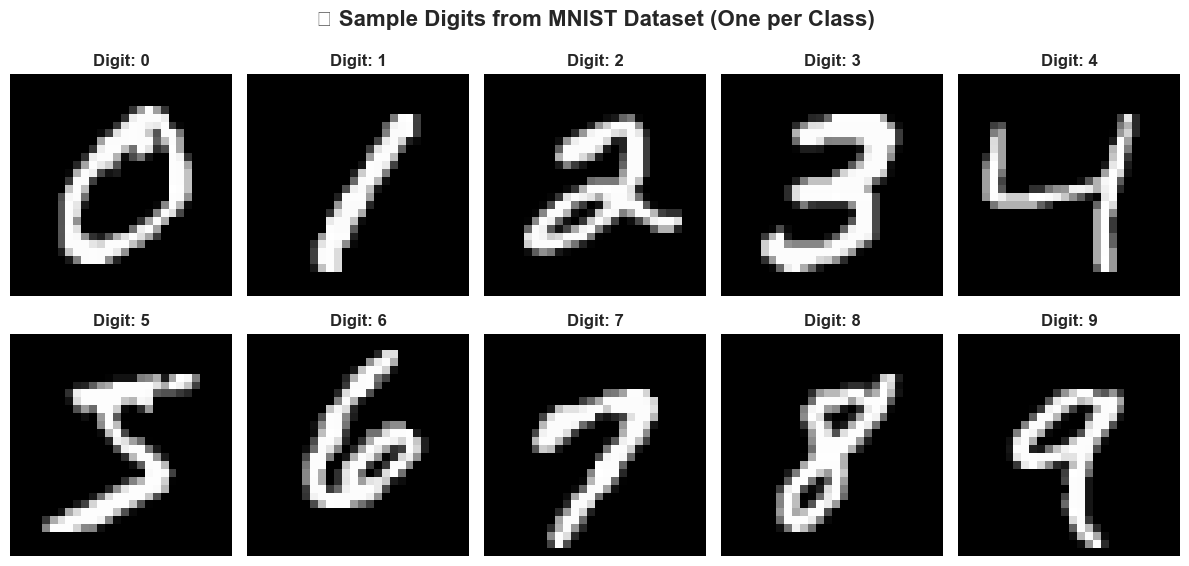

💡 Insight: Each digit has unique stroke patterns and shapes that ML models learn to recognize.


In [4]:
# Create a grid visualization of sample digits
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('🎨 Sample Digits from MNIST Dataset (One per Class)', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    # Find first occurrence of each digit
    idx = np.where(y_train == i)[0][0]
    ax.imshow(X_train[idx], cmap='gray', interpolation='nearest')
    ax.set_title(f'Digit: {i}', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("💡 Insight: Each digit has unique stroke patterns and shapes that ML models learn to recognize.")


C:\Users\786\AppData\Local\Temp\ipykernel_2972\1069034757.py:13: UserWarning: Glyph 9997 (\N{WRITING HAND}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\786\AppData\Local\Temp\ipykernel_2972\1069034757.py:13: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9997 (\N{WRITING HAND}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


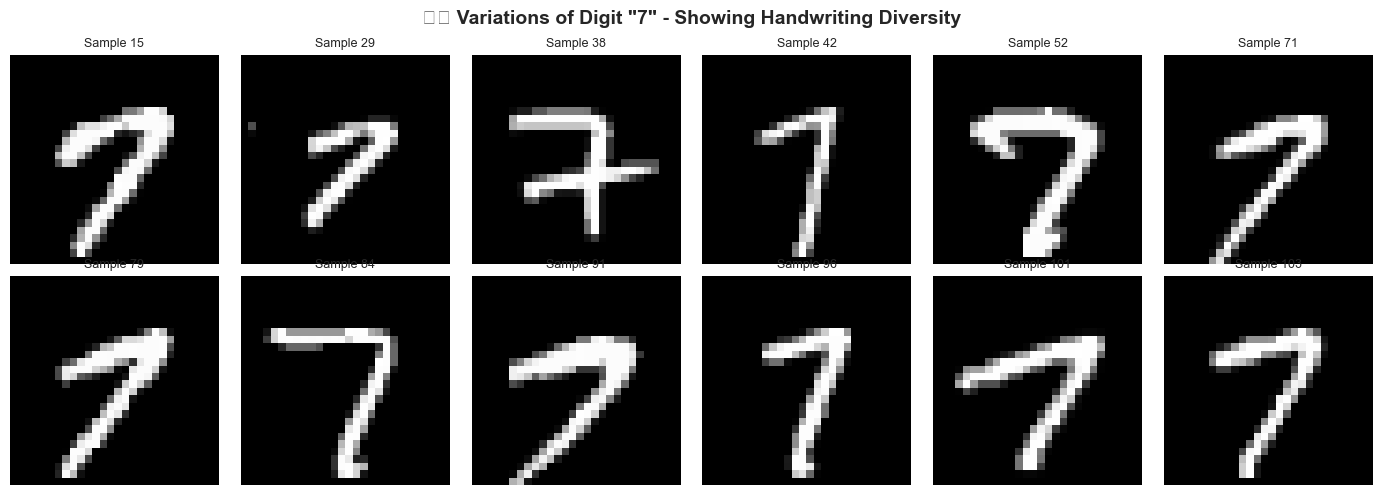

💡 Insight: Even for the same digit '7', there's significant variation in writing style,
   stroke thickness, and orientation. This diversity makes the dataset robust for training!


In [5]:
# Display multiple variations of the same digit to show handwriting diversity
digit_to_show = 7  # Change this to see different digits
indices = np.where(y_train == digit_to_show)[0][:12]

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
fig.suptitle(f'✍️ Variations of Digit "{digit_to_show}" - Showing Handwriting Diversity', fontsize=14, fontweight='bold')

for idx, ax in zip(indices, axes.flat):
    ax.imshow(X_train[idx], cmap='gray', interpolation='nearest')
    ax.set_title(f'Sample {idx}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"💡 Insight: Even for the same digit '{digit_to_show}', there's significant variation in writing style,")
print("   stroke thickness, and orientation. This diversity makes the dataset robust for training!")


## 5. Class Distribution Analysis

Understanding class balance is crucial for machine learning. Let's check if all digits are equally represented.


In [6]:
# Analyze class distribution in both training and test sets
train_counts = Counter(y_train)
test_counts = Counter(y_test)

# Create comparison dataframe
distribution_df = pd.DataFrame({
    'Digit': range(10),
    'Training_Count': [train_counts[i] for i in range(10)],
    'Test_Count': [test_counts[i] for i in range(10)]
})
distribution_df['Training_Pct'] = (distribution_df['Training_Count'] / len(y_train) * 100).round(2)
distribution_df['Test_Pct'] = (distribution_df['Test_Count'] / len(y_test) * 100).round(2)

print("📊 Class Distribution Analysis")
print("=" * 60)
print(distribution_df.to_string(index=False))
print("=" * 60)
print(f"✅ Most balanced class: {distribution_df.loc[distribution_df['Training_Pct'].idxmax(), 'Digit']} ({distribution_df['Training_Pct'].max():.2f}%)")
print(f"⚠️  Least balanced class: {distribution_df.loc[distribution_df['Training_Pct'].idxmin(), 'Digit']} ({distribution_df['Training_Pct'].min():.2f}%)")


📊 Class Distribution Analysis
 Digit  Training_Count  Test_Count  Training_Pct  Test_Pct
     0            5923         980          9.87      9.80
     1            6742        1135         11.24     11.35
     2            5958        1032          9.93     10.32
     3            6131        1010         10.22     10.10
     4            5842         982          9.74      9.82
     5            5421         892          9.04      8.92
     6            5918         958          9.86      9.58
     7            6265        1028         10.44     10.28
     8            5851         974          9.75      9.74
     9            5949        1009          9.92     10.09
✅ Most balanced class: 1 (11.24%)
⚠️  Least balanced class: 5 (9.04%)


C:\Users\786\AppData\Local\Temp\ipykernel_2972\2883051907.py:34: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\786\AppData\Local\Temp\ipykernel_2972\2883051907.py:34: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129514 (\N{TEST TUBE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


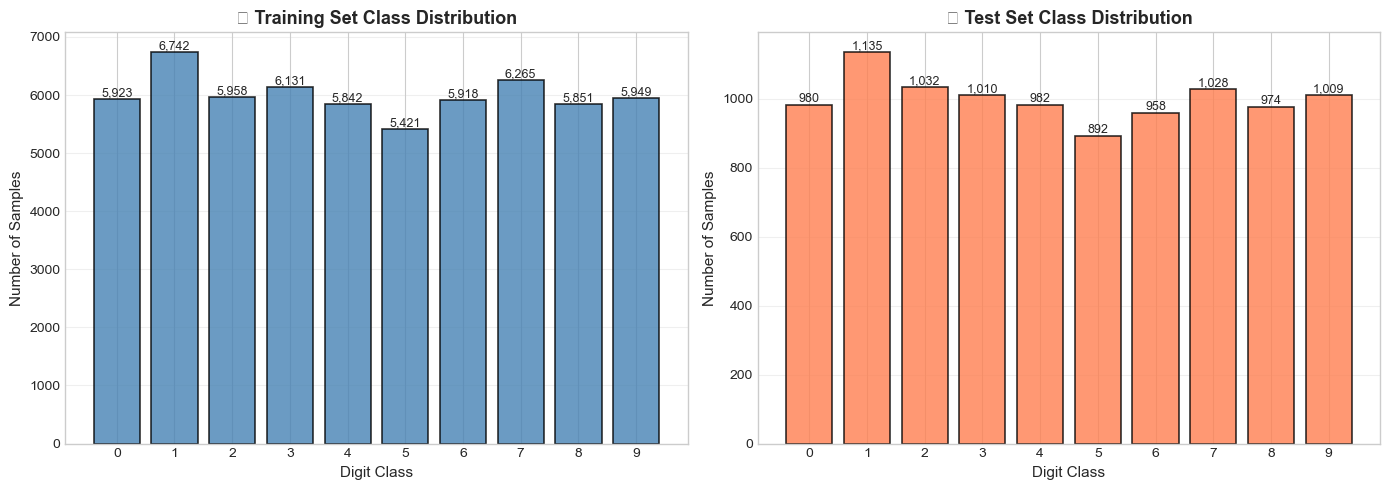

💡 Insight: MNIST is remarkably well-balanced! Each digit has roughly equal representation,
   which means we won't need special techniques to handle class imbalance. This is ideal for beginners!


In [7]:
# Visualize class distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training set distribution
bars1 = ax1.bar(distribution_df['Digit'], distribution_df['Training_Count'], 
                color='steelblue', alpha=0.8, edgecolor='black', linewidth=1.2)
ax1.set_title('📚 Training Set Class Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Digit Class', fontsize=11)
ax1.set_ylabel('Number of Samples', fontsize=11)
ax1.set_xticks(range(10))
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)

# Test set distribution
bars2 = ax2.bar(distribution_df['Digit'], distribution_df['Test_Count'], 
                color='coral', alpha=0.8, edgecolor='black', linewidth=1.2)
ax2.set_title('🧪 Test Set Class Distribution', fontsize=13, fontweight='bold')
ax2.set_xlabel('Digit Class', fontsize=11)
ax2.set_ylabel('Number of Samples', fontsize=11)
ax2.set_xticks(range(10))
ax2.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("💡 Insight: MNIST is remarkably well-balanced! Each digit has roughly equal representation,")
print("   which means we won't need special techniques to handle class imbalance. This is ideal for beginners!")


## 6. Pixel Intensity Analysis

Let's dive deeper into the pixel values themselves. Understanding intensity distributions helps with preprocessing decisions (like normalization).


In [8]:
# Calculate average pixel intensity for each class
avg_intensity_per_class = []
for digit in range(10):
    digit_images = X_train[y_train == digit]
    avg_intensity = np.mean(digit_images)
    avg_intensity_per_class.append(avg_intensity)

intensity_df = pd.DataFrame({
    'Digit': range(10),
    'Avg_Pixel_Intensity': avg_intensity_per_class
})

print("🔆 Average Pixel Intensity by Class")
print("=" * 40)
print(intensity_df.to_string(index=False))
print("=" * 40)
print(f"💡 Digit with highest avg intensity: {intensity_df.loc[intensity_df['Avg_Pixel_Intensity'].idxmax(), 'Digit']}")
print(f"💡 Digit with lowest avg intensity: {intensity_df.loc[intensity_df['Avg_Pixel_Intensity'].idxmin(), 'Digit']}")


🔆 Average Pixel Intensity by Class
 Digit  Avg_Pixel_Intensity
     0            44.216828
     1            19.379654
     2            37.988658
     3            36.090187
     4            30.948226
     5            32.831095
     6            35.011953
     7            29.204563
     8            38.289775
     9            31.260435
💡 Digit with highest avg intensity: 0
💡 Digit with lowest avg intensity: 1


C:\Users\786\AppData\Local\Temp\ipykernel_2972\373404361.py:29: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\786\AppData\Local\Temp\ipykernel_2972\373404361.py:29: UserWarning: Glyph 128262 (\N{HIGH BRIGHTNESS SYMBOL}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128262 (\N{HIGH BRIGHTNESS SYMBOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


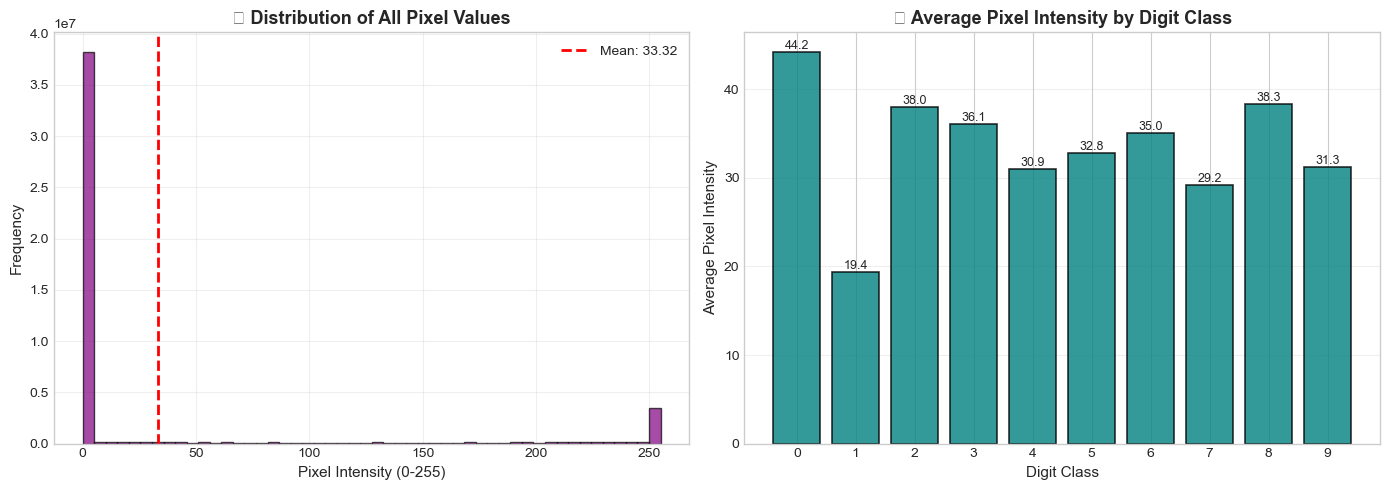

💡 Insight: Most pixels are black (0) or near-black, creating a sparse dataset.
   Digits like '1' have lower avg intensity (less ink), while '8' or '0' have more filled pixels!


In [9]:
# Visualize pixel intensity distribution across all images
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of all pixel values
all_pixels = X_train.flatten()
ax1.hist(all_pixels, bins=50, color='purple', alpha=0.7, edgecolor='black')
ax1.set_title('📊 Distribution of All Pixel Values', fontsize=13, fontweight='bold')
ax1.set_xlabel('Pixel Intensity (0-255)', fontsize=11)
ax1.set_ylabel('Frequency', fontsize=11)
ax1.axvline(x=all_pixels.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {all_pixels.mean():.2f}')
ax1.legend()
ax1.grid(alpha=0.3)

# Average intensity per class
bars = ax2.bar(intensity_df['Digit'], intensity_df['Avg_Pixel_Intensity'], 
               color='teal', alpha=0.8, edgecolor='black', linewidth=1.2)
ax2.set_title('🔆 Average Pixel Intensity by Digit Class', fontsize=13, fontweight='bold')
ax2.set_xlabel('Digit Class', fontsize=11)
ax2.set_ylabel('Average Pixel Intensity', fontsize=11)
ax2.set_xticks(range(10))
ax2.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("💡 Insight: Most pixels are black (0) or near-black, creating a sparse dataset.")
print("   Digits like '1' have lower avg intensity (less ink), while '8' or '0' have more filled pixels!")


## 7. Image Statistics

Let's compute statistics at the individual image level to understand variation within the dataset.


In [10]:
# Calculate statistics per image
image_stats = pd.DataFrame({
    'Image_Index': range(len(X_train)),
    'Label': y_train,
    'Mean_Intensity': [np.mean(img) for img in X_train],
    'Std_Intensity': [np.std(img) for img in X_train],
    'Min_Pixel': [np.min(img) for img in X_train],
    'Max_Pixel': [np.max(img) for img in X_train],
    'Non_Zero_Pixels': [np.count_nonzero(img) for img in X_train]
})

print("📈 Image-Level Statistics Summary")
print("=" * 60)
print(image_stats[['Mean_Intensity', 'Std_Intensity', 'Min_Pixel', 'Max_Pixel', 'Non_Zero_Pixels']].describe())
print("=" * 60)

# Show stats by class
print("\n📊 Mean Statistics by Digit Class:")
class_stats = image_stats.groupby('Label')[['Mean_Intensity', 'Std_Intensity', 'Non_Zero_Pixels']].mean()
print(class_stats.round(2))


📈 Image-Level Statistics Summary
       Mean_Intensity  Std_Intensity  Min_Pixel     Max_Pixel  Non_Zero_Pixels
count    60000.000000   60000.000000    60000.0  60000.000000     60000.000000
mean        33.318421      76.834539        0.0    254.900017       149.902600
std         11.041208      12.140855        0.0      0.299980        41.457372
min          6.487245      31.849565        0.0    254.000000        34.000000
25%         25.329082      68.553165        0.0    255.000000       122.000000
50%         32.483418      77.220602        0.0    255.000000       150.000000
75%         40.257653      85.370703        0.0    255.000000       178.000000
max        101.381378     119.159776        0.0    255.000000       351.000000

📊 Mean Statistics by Digit Class:
       Mean_Intensity  Std_Intensity  Non_Zero_Pixels
Label                                                
0               44.22          87.44           191.97
1               19.38          61.37            85.85
2    

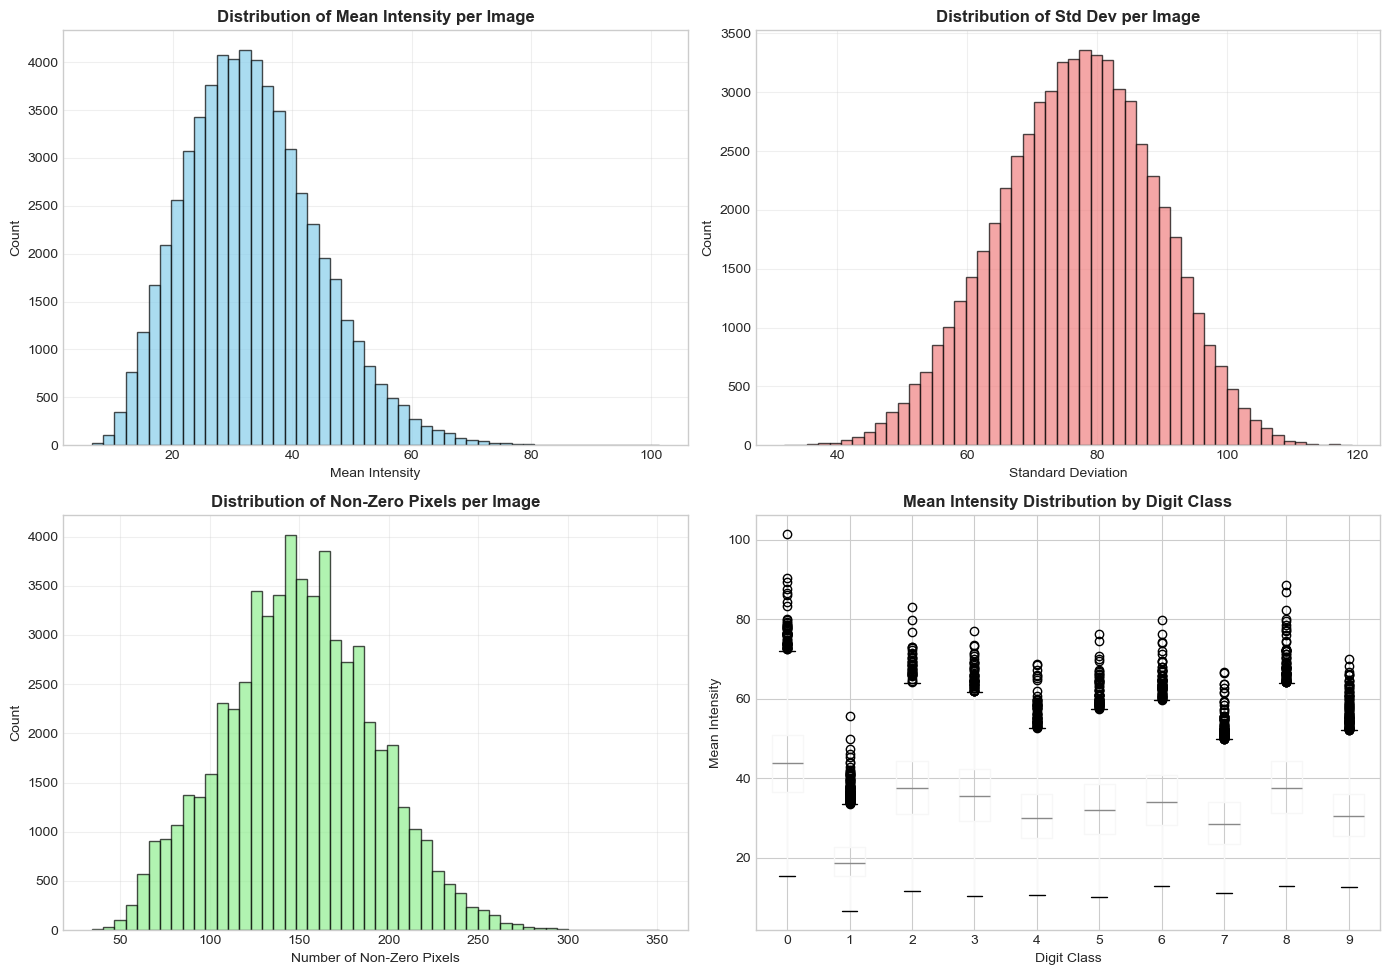

💡 Insight: The bimodal distribution in mean intensity suggests distinct 'light' and 'dark' digit styles.
   Standard deviation tells us about contrast - high std means sharp edges between black and white.


In [11]:
# Visualize distribution of image statistics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Mean intensity distribution
axes[0, 0].hist(image_stats['Mean_Intensity'], bins=50, color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('Distribution of Mean Intensity per Image', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Mean Intensity')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(alpha=0.3)

# Standard deviation distribution
axes[0, 1].hist(image_stats['Std_Intensity'], bins=50, color='lightcoral', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('Distribution of Std Dev per Image', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Standard Deviation')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(alpha=0.3)

# Non-zero pixels distribution
axes[1, 0].hist(image_stats['Non_Zero_Pixels'], bins=50, color='lightgreen', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Distribution of Non-Zero Pixels per Image', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Number of Non-Zero Pixels')
axes[1, 0].set_ylabel('Count')
axes[1, 0].grid(alpha=0.3)

# Box plot of mean intensity by class
image_stats.boxplot(column='Mean_Intensity', by='Label', ax=axes[1, 1])
axes[1, 1].set_title('Mean Intensity Distribution by Digit Class', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Digit Class')
axes[1, 1].set_ylabel('Mean Intensity')
plt.suptitle('')  # Remove default title

plt.tight_layout()
plt.show()

print("💡 Insight: The bimodal distribution in mean intensity suggests distinct 'light' and 'dark' digit styles.")
print("   Standard deviation tells us about contrast - high std means sharp edges between black and white.")


## 8. Dimensionality and Flattening

Understanding how 2D images become 1D feature vectors is essential for traditional ML models.


In [12]:
# Demonstrate flattening process
print("🔄 Understanding Image Flattening")
print("=" * 50)
print(f"Original image shape: {X_train[0].shape}")
print(f"Total pixels per image: {X_train[0].shape[0]} × {X_train[0].shape[1]} = {X_train[0].size}")

# Flatten a sample image
sample_image = X_train[0]
flattened = sample_image.flatten()

print(f"\nFlattened shape: {flattened.shape}")
print(f"First 20 pixel values: {flattened[:20]}")
print(f"Last 20 pixel values: {flattened[-20:]}")

# Show memory comparison
print(f"\n💾 Memory usage:")
print(f"   2D format: {sample_image.nbytes} bytes")
print(f"   1D format: {flattened.nbytes} bytes")
print(f"   (Same data, different view!)")


🔄 Understanding Image Flattening
Original image shape: (28, 28)
Total pixels per image: 28 × 28 = 784

Flattened shape: (784,)
First 20 pixel values: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Last 20 pixel values: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

💾 Memory usage:
   2D format: 784 bytes
   1D format: 784 bytes
   (Same data, different view!)


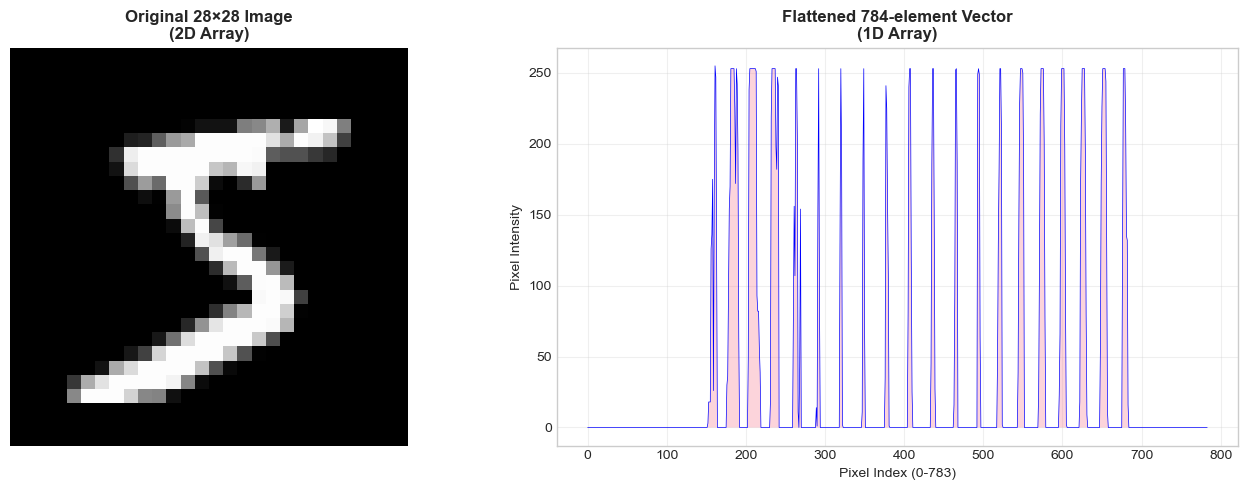

💡 Insight: Flattening loses spatial relationships (nearby pixels become far apart in the vector),
   which is why Convolutional Neural Networks (CNNs) keep the 2D structure for better performance!


In [13]:
# Visualize the flattening concept
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Show original image
ax1.imshow(sample_image, cmap='gray', interpolation='nearest')
ax1.set_title('Original 28×28 Image\n(2D Array)', fontsize=12, fontweight='bold')
ax1.axis('off')

# Show flattened representation (visualized as a line)
ax2.plot(flattened, color='blue', linewidth=0.5)
ax2.fill_between(range(len(flattened)), flattened, alpha=0.3)
ax2.set_title('Flattened 784-element Vector\n(1D Array)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Pixel Index (0-783)')
ax2.set_ylabel('Pixel Intensity')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Insight: Flattening loses spatial relationships (nearby pixels become far apart in the vector),")
print("   which is why Convolutional Neural Networks (CNNs) keep the 2D structure for better performance!")


## 9. Visualizing Average Digit per Class

Creating 'average' images for each class reveals the prototypical shape of each digit.


In [14]:
# Calculate average image for each digit class
average_digits = np.array([X_train[y_train == i].mean(axis=0) for i in range(10)])

print("🎨 Creating Average Digit Images...")
print(f"Shape of average_digits array: {average_digits.shape}")
print(f"Value range in averages: [{average_digits.min():.2f}, {average_digits.max():.2f}]")


🎨 Creating Average Digit Images...
Shape of average_digits array: (10, 28, 28)
Value range in averages: [0.00, 246.30]


C:\Users\786\AppData\Local\Temp\ipykernel_2972\699115435.py:13: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\786\miniconda3\envs\env_dl\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128290 (\N{INPUT SYMBOL FOR NUMBERS}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


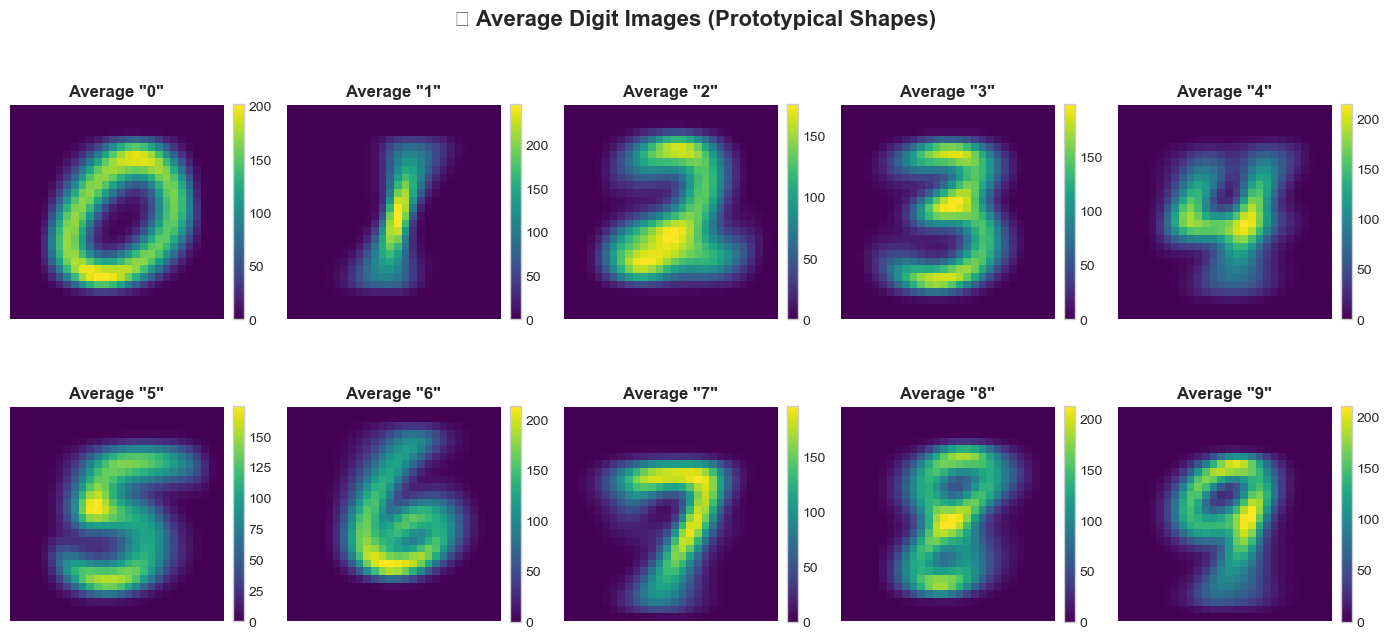

💡 Insight: Brighter areas (yellow) indicate pixels that are consistently active across all samples.
   Darker areas (purple) show variation in handwriting styles. The 'average 1' is very crisp!


In [15]:
# Visualize average digits with heatmap intensity
fig, axes = plt.subplots(2, 5, figsize=(14, 7))
fig.suptitle('🔢 Average Digit Images (Prototypical Shapes)', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    im = ax.imshow(average_digits[i], cmap='viridis', interpolation='nearest')
    ax.set_title(f'Average "{i}"', fontsize=12, fontweight='bold')
    ax.axis('off')
    
    # Add colorbar to show intensity
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("💡 Insight: Brighter areas (yellow) indicate pixels that are consistently active across all samples.")
print("   Darker areas (purple) show variation in handwriting styles. The 'average 1' is very crisp!")


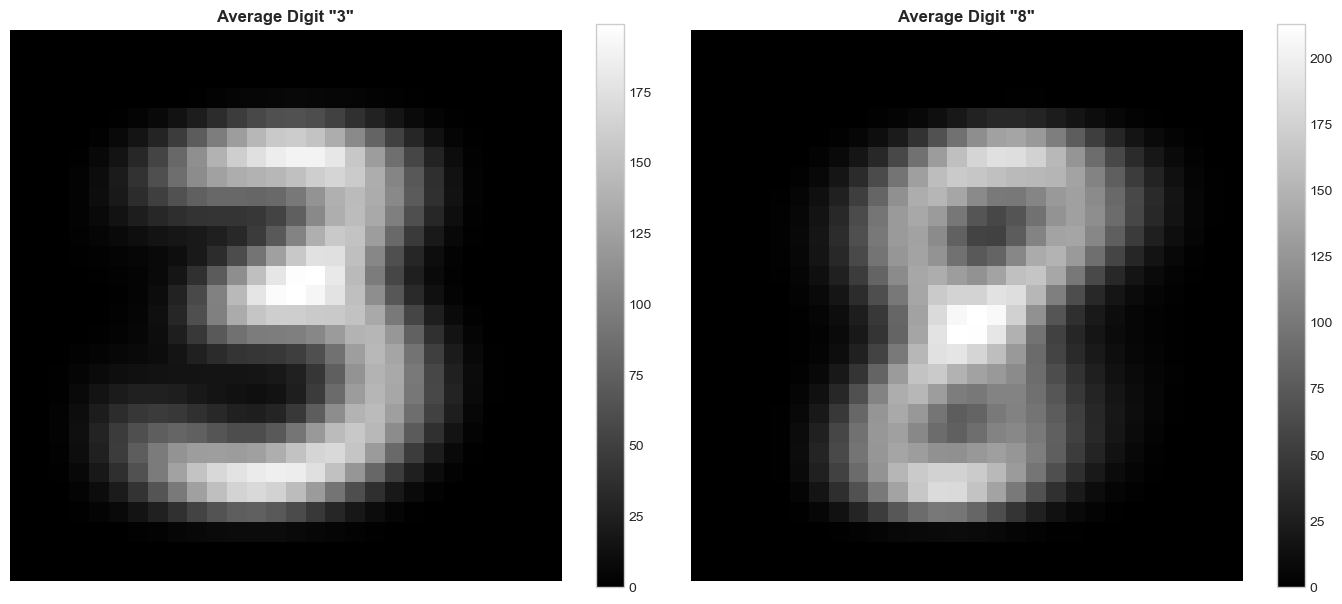

💡 Comparing digits '3' and '8':
   Mean absolute difference: 17.72
   Max difference: 151.27
   These differences are what a classifier learns to distinguish!


In [16]:
# Create a comparison heatmap showing differences between digits
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Side-by-side comparison of two similar digits
digit_a, digit_b = 3, 8  # These can be confused
diff_image = np.abs(average_digits[digit_a] - average_digits[digit_b])

im1 = axes[0].imshow(average_digits[digit_a], cmap='gray')
axes[0].set_title(f'Average Digit "{digit_a}"', fontsize=12, fontweight='bold')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0])

im2 = axes[1].imshow(average_digits[digit_b], cmap='gray')
axes[1].set_title(f'Average Digit "{digit_b}"', fontsize=12, fontweight='bold')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

print(f"💡 Comparing digits '{digit_a}' and '{digit_b}':")
print(f"   Mean absolute difference: {diff_image.mean():.2f}")
print(f"   Max difference: {diff_image.max():.2f}")
print("   These differences are what a classifier learns to distinguish!")


## 10. Key Insights for Computer Vision Modeling

Let's summarize what we've learned and how it applies to building ML models.


### 🧠 Key Insights from MNIST EDA

**Data Characteristics:**
- ✅ **Balanced Dataset**: All 10 classes have roughly equal representation (~6,000 training samples each)
- ✅ **Normalized Range**: Pixel values are already in [0, 255] range, making normalization straightforward
- ✅ **Consistent Size**: All images are exactly 28×28 pixels (no resizing needed)
- ✅ **Centered Content**: Digits are generally centered and size-normalized

**Modeling Implications:**
1. **No Class Imbalance Handling Needed**: Unlike many real-world datasets, MNIST is balanced
2. **Simple Preprocessing**: Just divide by 255.0 to normalize to [0, 1] range
3. **Feature Engineering**: 784 pixels can be used directly, or we can extract HOG features, etc.
4. **Baseline Models**: Even simple logistic regression achieves >90% accuracy on this dataset
5. **Advanced Models**: CNNs achieve >99% accuracy by preserving spatial structure

**Common Pitfalls to Avoid:**
- ⚠️ Don't flatten images for CNNs (use 2D convolutions instead)
- ⚠️ Remember that pixel position matters (spatial correlation is important)
- ⚠️ Watch for overfitting on this "easy" dataset when testing new architectures


## 11. Preparing Data for ML Models

Let's demonstrate the standard preprocessing pipeline for image data.


In [17]:
# Standard preprocessing pipeline for MNIST
print("⚙️ Data Preprocessing Pipeline")
print("=" * 50)

# Step 1: Normalize pixel values to [0, 1] range
X_train_normalized = X_train.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

print(f"✅ Step 1 - Normalization:")
print(f"   Original range: [{X_train.min()}, {X_train.max()}]")
print(f"   Normalized range: [{X_train_normalized.min():.3f}, {X_train_normalized.max():.3f}]")

# Step 2: Flatten for traditional ML models (optional)
X_train_flat = X_train_normalized.reshape(X_train_normalized.shape[0], -1)
X_test_flat = X_test_normalized.reshape(X_test_normalized.shape[0], -1)

print(f"\n✅ Step 2 - Flattening (for traditional ML):")
print(f"   Original shape: {X_train_normalized.shape}")
print(f"   Flattened shape: {X_train_flat.shape}")

# Step 3: One-hot encode labels (for neural networks)
from tensorflow.keras.utils import to_categorical
y_train_categorical = to_categorical(y_train, 10)
y_test_categorical = to_categorical(y_test, 10)

print(f"\n✅ Step 3 - Label Encoding:")
print(f"   Original label shape: {y_train.shape}")
print(f"   Categorical shape: {y_train_categorical.shape}")
print(f"   Example: Digit {y_train[0]} → {y_train_categorical[0]}")

print("\n🎯 Data ready for modeling!")


⚙️ Data Preprocessing Pipeline
✅ Step 1 - Normalization:
   Original range: [0, 255]
   Normalized range: [0.000, 1.000]

✅ Step 2 - Flattening (for traditional ML):
   Original shape: (60000, 28, 28)
   Flattened shape: (60000, 784)

✅ Step 3 - Label Encoding:
   Original label shape: (60000,)
   Categorical shape: (60000, 10)
   Example: Digit 5 → [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]

🎯 Data ready for modeling!


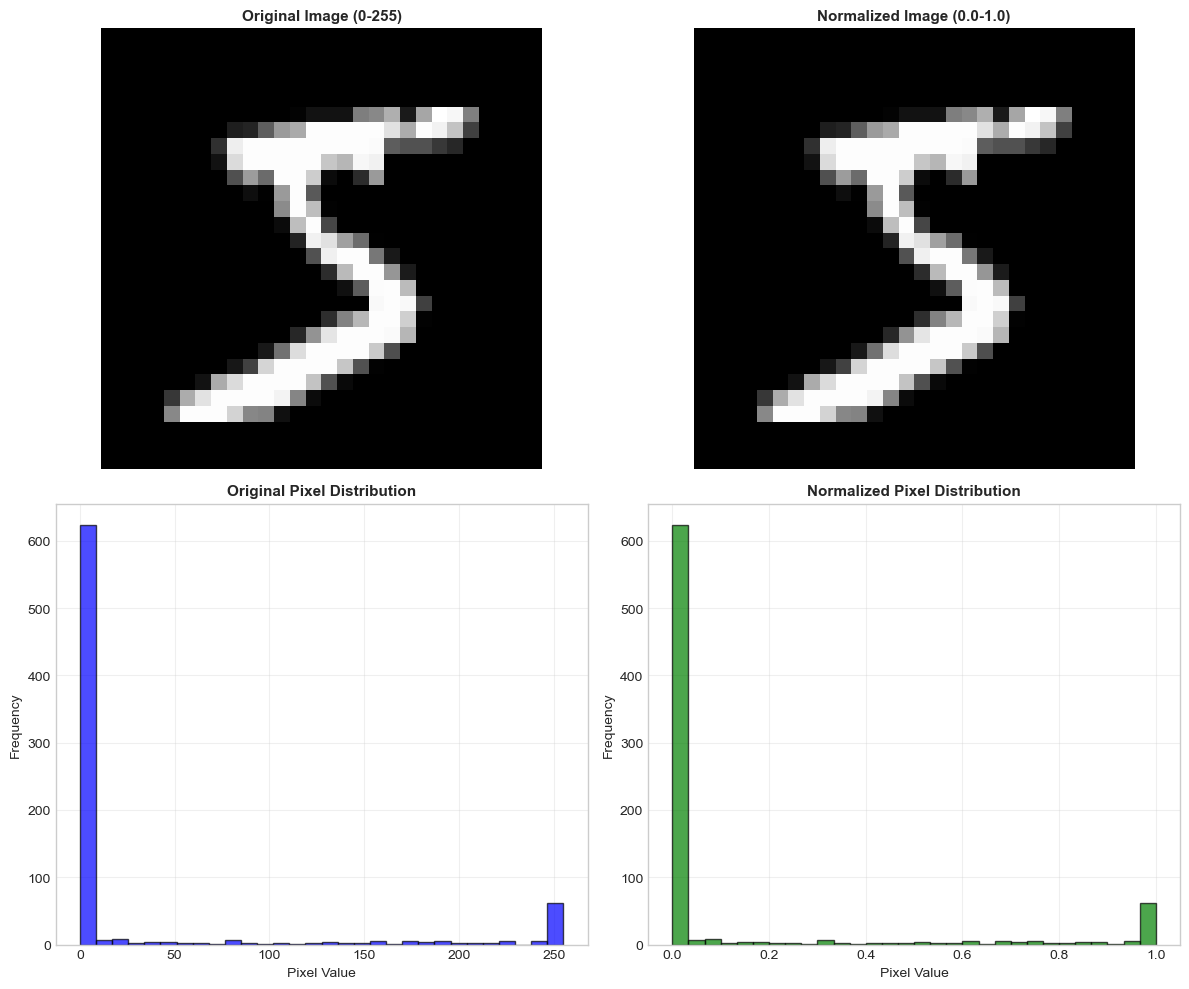

💡 Normalization helps neural networks train faster by keeping values in a similar range!


In [18]:
# Visualize before and after normalization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original image
axes[0, 0].imshow(X_train[0], cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Original Image (0-255)', fontsize=11, fontweight='bold')
axes[0, 0].axis('off')

# Normalized image
axes[0, 1].imshow(X_train_normalized[0], cmap='gray', vmin=0, vmax=1)
axes[0, 1].set_title('Normalized Image (0.0-1.0)', fontsize=11, fontweight='bold')
axes[0, 1].axis('off')

# Pixel distribution before
axes[1, 0].hist(X_train[0].flatten(), bins=30, color='blue', alpha=0.7, edgecolor='black')
axes[1, 0].set_title('Original Pixel Distribution', fontsize=11, fontweight='bold')
axes[1, 0].set_xlabel('Pixel Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].grid(alpha=0.3)

# Pixel distribution after
axes[1, 1].hist(X_train_normalized[0].flatten(), bins=30, color='green', alpha=0.7, edgecolor='black')
axes[1, 1].set_title('Normalized Pixel Distribution', fontsize=11, fontweight='bold')
axes[1, 1].set_xlabel('Pixel Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Normalization helps neural networks train faster by keeping values in a similar range!")


## 🛠️ Hands-On Exercises

Now it's your turn to practice! Complete these exercises to reinforce your understanding of image data exploration.

**Instructions**: Each exercise has an empty code cell below it. Write your code there and run it. Check the Solutions section only after attempting!


### Exercise 1: Visualize More Samples 📸
Create a 5×5 grid showing 25 random samples from the training set, with their labels as titles.


### Exercise 2: Create Average Digit Heatmaps 🔥
Create a single figure showing all 10 average digits side-by-side in a 2×5 grid using the 'hot' colormap instead of grayscale.


### Exercise 3: Analyze Pixel Intensity Differences 📊
Calculate and visualize the standard deviation (variability) of each pixel position across all images of digit '3'. Which pixels vary the most?


### Exercise 4: Explore Class Similarity 🔍
Create a similarity matrix showing how similar each pair of digit classes is (using correlation between average images). Which digits are most easily confused?


### Exercise 5: Edge Detection Visualization 🎨
Use simple gradient operations (np.gradient) to visualize the edges of a sample digit. Display original, horizontal edges, and vertical edges side-by-side.


### Exercise 6: Thickness Analysis ✏️
Create a function that calculates the 'thickness' of a digit by counting non-zero pixels. Compare thickness across all classes using a bar chart.


### Exercise 7: Outlier Detection 🚨
Find the "weirdest" example of digit '5' by finding the image with the highest mean squared error compared to the average '5'.


### Exercise 8: Data Augmentation Preview 🔄
Implement a simple horizontal flip on a digit image and display before/after. (Hint: Use np.fliplr). Does the flipped version still look like the same digit?


### Exercise 9: Centroid Analysis 📍
Calculate the center of mass (centroid) for each digit class. Do certain digits tend to be written higher or lower in the 28×28 box?


### Exercise 10: Prepare ML-Ready Dataset 🎯
Create a function that takes the raw MNIST data and returns a fully preprocessed version suitable for scikit-learn (flattened, normalized, with train/validation split).


## Solutions & Key Insights (Review After Attempting)

Below are detailed solutions and explanations for each exercise. Review these after you've attempted the problems!


### ✅ Exercise 1 Solution: Visualize More Samples

```python
# Create a 5x5 grid of random samples
fig, axes = plt.subplots(5, 5, figsize=(12, 12))
fig.suptitle('25 Random Samples from MNIST Training Set', fontsize=14, fontweight='bold')

# Generate random indices
random_indices = np.random.choice(len(X_train), 25, replace=False)

for idx, ax in zip(random_indices, axes.flat):
    ax.imshow(X_train[idx], cmap='gray', interpolation='nearest')
    ax.set_title(f'Label: {y_train[idx]}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()
```

**Key Insight**: Random sampling gives you a realistic view of the dataset's diversity and helps spot any data quality issues.


### ✅ Exercise 2 Solution: Average Digit Heatmaps

```python
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('Average Digit Heatmaps (Hot Colormap)', fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    im = ax.imshow(average_digits[i], cmap='hot', interpolation='nearest')
    ax.set_title(f'Average "{i}"', fontsize=11, fontweight='bold')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()
```

**Key Insight**: Different colormaps emphasize different aspects. 'Hot' makes high-intensity regions (common strokes) stand out clearly.


### ✅ Exercise 3 Solution: Pixel Variability Analysis

```python
# Get all images of digit 3
digit_3_images = X_train[y_train == 3]

# Calculate standard deviation at each pixel position
pixel_std = np.std(digit_3_images, axis=0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Show average 3
ax1.imshow(average_digits[3], cmap='gray')
ax1.set_title('Average Digit "3"', fontsize=12, fontweight='bold')
ax1.axis('off')

# Show variability heatmap
im = ax2.imshow(pixel_std, cmap='Reds')
ax2.set_title('Pixel Variability (Std Dev) for Digit "3"', fontsize=12, fontweight='bold')
ax2.axis('off')
plt.colorbar(im, ax=ax2)

plt.tight_layout()
plt.show()

print(f"Highest variability at pixel: {np.unravel_index(np.argmax(pixel_std), pixel_std.shape)}")
```

**Key Insight**: High variability areas (bright red) indicate where handwriting styles differ most. The ends of strokes usually vary more than the middle.


### ✅ Exercise 4 Solution: Class Similarity Matrix

```python
# Calculate correlation between average images
similarity_matrix = np.zeros((10, 10))

for i in range(10):
    for j in range(10):
        # Flatten and calculate correlation
        corr = np.corrcoef(average_digits[i].flatten(), average_digits[j].flatten())[0, 1]
        similarity_matrix[i, j] = corr

# Visualize as heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(similarity_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            xticklabels=range(10), yticklabels=range(10), 
            center=0, square=True, linewidths=0.5)
plt.title('Digit Class Similarity Matrix (Correlation)', fontsize=14, fontweight='bold')
plt.xlabel('Digit Class', fontsize=12)
plt.ylabel('Digit Class', fontsize=12)
plt.show()

# Find most similar pair (excluding diagonal)
np.fill_diagonal(similarity_matrix, 0)  # Zero out diagonal
most_similar = np.unravel_index(np.argmax(similarity_matrix), similarity_matrix.shape)
print(f"Most similar digits: {most_similar[0]} and {most_similar[1]} (correlation: {similarity_matrix[most_similar]:.3f})")
```

**Key Insight**: Similar-looking digits (like 4/9, 3/8, 5/6) have high correlation. These pairs are commonly confused by classifiers!


### ✅ Exercise 5 Solution: Edge Detection

```python
# Select a sample image
sample = X_train_normalized[0]

# Calculate gradients
grad_y, grad_x = np.gradient(sample)

# Calculate magnitude
edge_magnitude = np.sqrt(grad_x**2 + grad_y**2)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(sample, cmap='gray')
axes[0].set_title('Original', fontsize=11, fontweight='bold')
axes[0].axis('off')

axes[1].imshow(grad_x, cmap='RdBu', vmin=-0.5, vmax=0.5)
axes[1].set_title('Horizontal Edges', fontsize=11, fontweight='bold')
axes[1].axis('off')

axes[2].imshow(grad_y, cmap='RdBu', vmin=-0.5, vmax=0.5)
axes[2].set_title('Vertical Edges', fontsize=11, fontweight='bold')
axes[2].axis('off')

axes[3].imshow(edge_magnitude, cmap='hot')
axes[3].set_title('Edge Magnitude', fontsize=11, fontweight='bold')
axes[3].axis('off')

plt.tight_layout()
plt.show()

print("💡 Edge detection highlights boundaries where pixel values change rapidly - key features for recognition!")
```

**Key Insight**: Edges contain the most important shape information. This is why edge detection is often a preprocessing step in traditional computer vision.


### ✅ Exercise 6 Solution: Thickness Analysis

```python
def calculate_thickness(images, threshold=0):
    """Calculate average 'thickness' (non-zero pixels) for a set of images."""
    return np.mean([np.count_nonzero(img > threshold) for img in images])

# Calculate thickness for each class
thickness_by_class = []
for i in range(10):
    digit_images = X_train[y_train == i]
    thickness = calculate_thickness(digit_images)
    thickness_by_class.append(thickness)

# Visualize
plt.figure(figsize=(10, 6))
bars = plt.bar(range(10), thickness_by_class, color='teal', alpha=0.8, edgecolor='black')
plt.title('Average Digit Thickness by Class (Non-Zero Pixel Count)', fontsize=13, fontweight='bold')
plt.xlabel('Digit Class', fontsize=11)
plt.ylabel('Average Non-Zero Pixels', fontsize=11)
plt.xticks(range(10))
plt.grid(axis='y', alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

thickest = np.argmax(thickness_by_class)
thinnest = np.argmin(thickness_by_class)
print(f"Thickest digit: {thickest} ({thickness_by_class[thickest]:.0f} pixels)")
print(f"Thinnest digit: {thinnest} ({thickness_by_class[thinnest]:.0f} pixels)")
```

**Key Insight**: Digit '1' is typically the thinnest (simple stroke), while '8' and '0' are thickest (more loops and enclosed areas).


### ✅ Exercise 7 Solution: Outlier Detection

```python
# Get all 5s
digit_5_indices = np.where(y_train == 5)[0]
digit_5_images = X_train_normalized[digit_5_indices]
average_5 = average_digits[5] / 255.0  # Normalize to match

# Calculate MSE for each image compared to average
mse_scores = []
for img in digit_5_images:
    mse = np.mean((img - average_5)**2)
    mse_scores.append(mse)

mse_scores = np.array(mse_scores)
weirdest_idx = digit_5_indices[np.argmax(mse_scores)]

# Visualize
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(average_5, cmap='gray')
ax1.set_title('Average "5"', fontsize=12, fontweight='bold')
ax1.axis('off')

ax2.imshow(X_train[weirdest_idx], cmap='gray')
ax2.set_title(f'Weirdest "5" (MSE: {np.max(mse_scores):.4f})', fontsize=12, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

print(f"Weirdest '5' is at index: {weirdest_idx}")
print("This outlier detection method can help identify mislabeled or unusual samples in your dataset!")
```

**Key Insight**: Outliers in image data often indicate labeling errors, unusual writing styles, or data quality issues. Always inspect your outliers!


### ✅ Exercise 8 Solution: Data Augmentation

```python
# Select a sample
sample_idx = np.where(y_train == 3)[0][0]
original = X_train[sample_idx]
flipped = np.fliplr(original)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

ax1.imshow(original, cmap='gray')
ax1.set_title('Original "3"', fontsize=12, fontweight='bold')
ax1.axis('off')

ax2.imshow(flipped, cmap='gray')
ax2.set_title('Horizontally Flipped "3"', fontsize=12, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

print("💡 The flipped '3' looks like a backwards '3' or could be mistaken for a weird 'E'!")
print("   This is why augmentation strategies must be domain-aware. Flipping works for some datasets (symmetrical objects)")
print("   but not for digits where orientation matters.")
```

**Key Insight**: Not all augmentations are appropriate for all data types. Flipping a '6' creates a '9', which changes the label! Always consider semantic validity.


### ✅ Exercise 9 Solution: Centroid Analysis

```python
def calculate_centroid(image):
    """Calculate center of mass of an image."""
    y_indices, x_indices = np.indices(image.shape)
    total_mass = np.sum(image)
    if total_mass == 0:
        return image.shape[0] / 2, image.shape[1] / 2
    cy = np.sum(y_indices * image) / total_mass
    cx = np.sum(x_indices * image) / total_mass
    return cy, cx

# Calculate centroids for average digits
centroids = [calculate_centroid(avg) for avg in average_digits]

# Visualize centroids on average images
fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle('Centroid Positions for Each Digit Class (Red Cross)', fontsize=14, fontweight='bold')

for i, (ax, (cy, cx)) in enumerate(zip(axes.flat, centroids)):
    ax.imshow(average_digits[i], cmap='gray')
    ax.plot(cx, cy, 'r+', markersize=15, markeredgewidth=2)
    ax.set_title(f'Digit {i}\nCenter: ({cy:.1f}, {cx:.1f})', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Analyze vertical positions
vertical_positions = [c[0] for c in centroids]
plt.figure(figsize=(10, 6))
plt.bar(range(10), vertical_positions, color='orange', alpha=0.8, edgecolor='black')
plt.axhline(y=14, color='red', linestyle='--', label='Center Line (14)')
plt.title('Vertical Centroid Position by Digit Class', fontsize=13, fontweight='bold')
plt.xlabel('Digit Class')
plt.ylabel('Vertical Position (pixels from top)')
plt.xticks(range(10))
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

highest = np.argmin(vertical_positions)  # Lower number = higher up
lowest = np.argmax(vertical_positions)
print(f"Digit written highest: {highest} (y={vertical_positions[highest]:.2f})")
print(f"Digit written lowest: {lowest} (y={vertical_positions[lowest]:.2f})")
```

**Key Insight**: Some digits (like '1') tend to be written higher or lower due to writing habits. This positional information could be a feature for classification!


### ✅ Exercise 10 Solution: ML-Ready Dataset Function

```python
from sklearn.model_selection import train_test_split

def prepare_mnist_for_ml(X_train, y_train, X_test, y_test, validation_split=0.2):
    """
    Fully preprocess MNIST data for traditional ML models.
    
    Returns:
        X_train_processed, X_val, X_test_processed, y_train, y_val, y_test
    """
    # Normalize
    X_train_norm = X_train.astype('float32') / 255.0
    X_test_norm = X_test.astype('float32') / 255.0
    
    # Flatten
    X_train_flat = X_train_norm.reshape(X_train_norm.shape[0], -1)
    X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)
    
    # Create validation split from training data
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_flat, y_train, 
        test_size=validation_split, 
        random_state=42, 
        stratify=y_train  # Maintain class balance
    )
    
    print("✅ Data Preprocessing Complete!")
    print(f"   Training set: {X_tr.shape}")
    print(f"   Validation set: {X_val.shape}")
    print(f"   Test set: {X_test_flat.shape}")
    print(f"   Feature range: [{X_tr.min():.3f}, {X_tr.max():.3f}]")
    
    return X_tr, X_val, X_test_flat, y_tr, y_val, y_test

# Test the function
X_tr, X_val, X_te, y_tr, y_va, y_te = prepare_mnist_for_ml(X_train, y_train, X_test, y_test)

# Verify shapes
print("\n📊 Verification:")
print(f"Training features shape: {X_tr.shape}")
print(f"Training labels shape: {y_tr.shape}")
print(f"Classes in training: {np.unique(y_tr)}")
```

**Key Insight**: A robust preprocessing pipeline includes normalization, reshaping, and proper train/validation splits. Stratification ensures all classes are represented in each split!
